# Parametric Curve Parameter Estimation

This notebook estimates the unknown parameters $\theta$, $M$, and $X$ of a given parametric curve using the supplied observed $(x,y)$ data.

## 1. Problem Statement

The objective is to estimate the unknown parameters $\theta$, $M$, and $X$ of the following parametric curve:

$$
x(t)=t\cos(\theta)-e^{M|t|}\sin(0.3t)\sin(\theta)+X
$$

$$
y(t)=42+t\sin(\theta)+e^{M|t|}\sin(0.3t)\cos(\theta)
$$

The parameter constraints are:

$$
0^\circ < \theta < 50^\circ
$$

$$
-0.05 < M < 0.05
$$

$$
0 < X < 100
$$

with:

$$
6<t<60.
$$

The supplied dataset contains observed $(x,y)$ points generated from the unknown parametric curve.

## 2. Objective of the Analysis

The main goal is to determine values of \(\theta\), \(M\), and \(X\) that make the given parametric model agree as closely as possible with the supplied observed data.

The procedure consists of the following stages:

1. Load and inspect the supplied dataset.
2. Visualize the observed \((x,y)\) points.
3. Reformulate the parametric equations to recover the latent parameter \(t\).
4. Define an objective function measuring the discrepancy between the observations and the mathematical model.
5. Perform bounded numerical optimization to estimate \(\theta\), \(M\), and \(X\).
6. Verify that the estimated parameters satisfy all given constraints.
7. Reconstruct the parametric curve using the estimated parameters.
8. Compare the reconstructed curve with the observed data.
9. Evaluate the reconstruction using the L1 distance.
10. Perform additional convergence and robustness checks.

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, minimize

print("Libraries imported successfully.")

Libraries imported successfully.


In [91]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sravanisitamsetti/xy-data/xy_data.csv


## 3. Dataset Loading

The supplied dataset contains observed \((x,y)\) coordinates generated from the unknown parametric curve.

The dataset is loaded into a Pandas DataFrame for further analysis. The two columns are:

- \(x\): observed x-coordinate
- \(y\): observed y-coordinate

The dataset is then examined to determine its size, column names, data types, missing values, duplicate records, and basic statistical properties.

In [92]:
import glob
import pandas as pd

# Find the CSV file automatically
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/datasets/sravanisitamsetti/xy-data/xy_data.csv


In [93]:
# Load the assignment dataset

file_path = csv_files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

display(df.head(10))

Dataset loaded successfully.
Shape of dataset: (1500, 2)


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340
5,69.284134,48.406086
6,77.810130,57.588833
7,91.296880,63.031350
8,107.668410,65.914050
9,76.406890,56.871525


## 4. Dataset Inspection

After loading the dataset, several checks are performed to verify its quality and structure.

The following properties are examined:

1. Number of observations and variables.
2. Column names.
3. Data types.
4. Missing values.
5. Duplicate rows.
6. Basic statistical summary of the observed coordinates.

These checks ensure that the supplied data can be used directly for the parameter-estimation procedure.

In [94]:
# Dataset inspection

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nBasic statistical summary:")
display(df.describe())

Column names:
['x', 'y']

Data types:
x    float64
y    float64
dtype: object

Missing values:
x    0
y    0
dtype: int64

Number of duplicate rows:
0

Basic statistical summary:


,x,y
count,1500.000000,1500.000000
mean,83.713931,58.263519
std,13.697157,7.696524
min,59.657204,46.032295
25%,72.282910,51.124211
50%,84.710995,57.681288
75%,93.368257,66.138374
max,109.231520,69.685510


In [95]:
# Extract x and y coordinates

x_data = df["x"].to_numpy(dtype=float)
y_data = df["y"].to_numpy(dtype=float)

print("Number of x values:", len(x_data))
print("Number of y values:", len(y_data))

Number of x values: 1500
Number of y values: 1500


## 5. Visualization of Observed Data

The observed \((x,y)\) coordinates are visualized using a scatter plot.

Since the CSV file contains only the observed coordinates and does not explicitly provide the corresponding \(t\)-values, the points are initially plotted in their supplied coordinate form.

The visualization provides an initial understanding of the geometric shape of the unknown parametric curve and helps verify that the dataset forms a smooth curve rather than random unstructured observations.

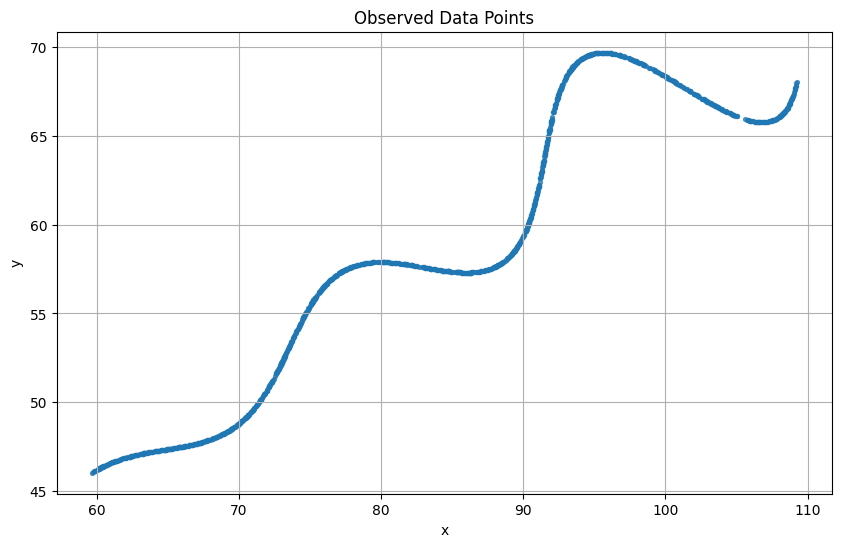

In [96]:
# Visualize the observed data points

plt.figure(figsize=(10, 6))

plt.scatter(
    x_data,
    y_data,
    s=8,
    alpha=0.7
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Data Points")
plt.grid(True)

plt.show()

## 6. Mathematical Reformulation

The given parametric curve is

\[
x(t)=t\cos(\theta)-e^{M|t|}\sin(0.3t)\sin(\theta)+X
\]

\[
y(t)=42+t\sin(\theta)+e^{M|t|}\sin(0.3t)\cos(\theta)
\]

with the constraints

\[
0^\circ<\theta<50^\circ,
\]

\[
-0.05<M<0.05,
\]

\[
0<X<100,
\]

and

\[
6<t<60.
\]

The supplied dataset contains only the observed coordinates \((x_i,y_i)\), and the corresponding values of \(t_i\) are not provided.

Since the complete range of \(t\) is positive,

\[
6<t<60 \implies |t|=t.
\]

Therefore, the curve can be simplified to

\[
x(t)=t\cos(\theta)-e^{Mt}\sin(0.3t)\sin(\theta)+X
\]

\[
y(t)=42+t\sin(\theta)+e^{Mt}\sin(0.3t)\cos(\theta).
\]

Define

\[
A(t)=e^{Mt}\sin(0.3t).
\]

Then the equations become

\[
x-X=t\cos(\theta)-A(t)\sin(\theta)
\]

and

\[
y-42=t\sin(\theta)+A(t)\cos(\theta).
\]

This can be written in matrix form as

\[
\begin{bmatrix}
x-X\\
y-42
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta&-\sin\theta\\
\sin\theta&\cos\theta
\end{bmatrix}
\begin{bmatrix}
t\\
A(t)
\end{bmatrix}.
\]

The matrix is a two-dimensional rotation matrix. Its inverse is

\[
\begin{bmatrix}
t\\
A(t)
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta&\sin\theta\\
-\sin\theta&\cos\theta
\end{bmatrix}
\begin{bmatrix}
x-X\\
y-42
\end{bmatrix}.
\]

Therefore, for any candidate values of \(\theta\) and \(X\), the corresponding parameter value \(t\) can be estimated from

\[
t=(x-X)\cos\theta+(y-42)\sin\theta.
\]

Similarly,

\[
A=-(x-X)\sin\theta+(y-42)\cos\theta.
\]

The theoretical relationship between \(A\) and \(t\) is

\[
A=e^{Mt}\sin(0.3t).
\]

Thus, the unknown parameters can be estimated by finding values of

\[
(\theta,M,X)
\]

that make the transformed observations satisfy

\[
A_i\approx e^{Mt_i}\sin(0.3t_i)
\]

while keeping the recovered \(t_i\) values within

\[
6<t_i<60.
\]

In [97]:
# Transform observed coordinates into the underlying (t, A) coordinates

def transformed_values(params, x, y):
    theta_deg, M, X = params
    theta = np.deg2rad(theta_deg)

    # Recover the hidden parameter t
    t = (
        (x - X) * np.cos(theta)
        + (y - 42) * np.sin(theta)
    )

    # Recover A(t)
    A = (
        -(x - X) * np.sin(theta)
        + (y - 42) * np.cos(theta)
    )

    # Theoretical value of A(t)
    A_model = np.exp(M * t) * np.sin(0.3 * t)

    return t, A, A_model

print("Transformation function defined successfully.")

Transformation function defined successfully.


## 7. Parameter Estimation Objective

For a candidate parameter vector

\[
(\theta,M,X),
\]

the transformation gives an estimated \(t_i\) and \(A_i\) for every observed point.

The model requires

\[
A_i=e^{Mt_i}\sin(0.3t_i).
\]

Therefore, the residual for each observation is

\[
r_i=A_i-e^{Mt_i}\sin(0.3t_i).
\]

We define the data-fitting error as the mean squared residual:

\[
E_{\text{data}}
=
\frac{1}{N}
\sum_{i=1}^{N}r_i^2.
\]

In addition, the recovered values of \(t_i\) should satisfy

\[
6<t_i<60.
\]

A penalty is therefore added when any recovered \(t_i\) falls outside the allowed interval.

The final objective function is

\[
E(\theta,M,X)
=
E_{\text{data}}
+
\lambda E_{\text{penalty}},
\]

where \(\lambda\) is a sufficiently large penalty coefficient.

The optimization problem is consequently

\[
\min_{\theta,M,X} E(\theta,M,X)
\]

subject to

\[
0^\circ<\theta<50^\circ,
\]

\[
-0.05<M<0.05,
\]

\[
0<X<100.
\]

In [98]:
# Define the objective function for parameter estimation

def objective(params):
    theta_deg, M, X = params

    # Transform observed points
    t, A, A_model = transformed_values(
        params,
        x_data,
        y_data
    )

    # Residual between observed and theoretical A(t)
    residual = A - A_model

    # Data-fitting error
    data_error = np.mean(residual**2)

    # Penalty for violating 6 < t < 60
    lower_violation = np.maximum(6 - t, 0)
    upper_violation = np.maximum(t - 60, 0)

    penalty = np.mean(
        lower_violation**2 +
        upper_violation**2
    )

    # Combined objective
    total_error = data_error + 1000 * penalty

    return total_error


print("Objective function defined successfully.")

Objective function defined successfully.


In [99]:
# Parameter bounds from the assignment

bounds = [
    (0.001, 49.999),       # theta in degrees
    (-0.049999, 0.049999), # M
    (0.001, 99.999)        # X
]

print("Parameter bounds:")
print("theta:", bounds[0])
print("M:", bounds[1])
print("X:", bounds[2])

Parameter bounds:
theta: (0.001, 49.999)
M: (-0.049999, 0.049999)
X: (0.001, 99.999)


## 8. Numerical Optimization

The unknown parameters are estimated using a global numerical optimization procedure.

Differential Evolution is used because the objective function is nonlinear and the parameters interact with one another through the rotation and exponential terms.

The optimizer searches within the prescribed parameter bounds:

\[
0.001\leq\theta\leq49.999,
\]

\[
-0.049999\leq M\leq0.049999,
\]

\[
0.001\leq X\leq99.999.
\]

For each candidate parameter vector \((\theta,M,X)\), the objective function:

1. recovers the implied values of \(t_i\),
2. computes the transformed values \(A_i\),
3. compares them with \(e^{Mt_i}\sin(0.3t_i)\),
4. penalizes recovered \(t_i\) values outside the interval \(6<t_i<60\).

The parameter vector producing the smallest objective value is selected as the estimated solution.

In [100]:
# Global numerical optimization using Differential Evolution

result = differential_evolution(
    objective,
    bounds=bounds,
    seed=42,
    popsize=20,
    maxiter=1000,
    tol=1e-10,
    polish=True
)

print("Optimization completed.")
print("Best objective value:", result.fun)
print("Estimated parameters:")
print("theta =", result.x[0], "degrees")
print("M     =", result.x[1])
print("X     =", result.x[2])

Optimization completed.
Best objective value: 1.2153319572924786e-11
Estimated parameters:
theta = 29.999972932157075 degrees
M     = 0.029999996873213048
X     = 54.9999982127934


In [101]:
# Extract optimized parameter values

theta_final = result.x[0]
M_final = result.x[1]
X_final = result.x[2]

print("Final estimated parameters")
print("--------------------------")
print(f"theta = {theta_final:.10f} degrees")
print(f"M     = {M_final:.12f}")
print(f"X     = {X_final:.10f}")
print(f"Objective value = {result.fun:.12e}")

Final estimated parameters
--------------------------
theta = 29.9999729322 degrees
M     = 0.029999996873
X     = 54.9999982128
Objective value = 1.215331957292e-11


In [102]:
# Check whether the estimated parameters satisfy the assignment constraints

theta_valid = 0 < theta_final < 50
M_valid = -0.05 < M_final < 0.05
X_valid = 0 < X_final < 100

print("Constraint validation")
print("---------------------")
print(f"0 < theta < 50      : {theta_valid}")
print(f"-0.05 < M < 0.05    : {M_valid}")
print(f"0 < X < 100         : {X_valid}")

print("\nAll parameter constraints satisfied:",
      theta_valid and M_valid and X_valid)

Constraint validation
---------------------
0 < theta < 50      : True
-0.05 < M < 0.05    : True
0 < X < 100         : True

All parameter constraints satisfied: True


In [103]:
# Recover the hidden t values using the estimated parameters

t_recovered, A_recovered, A_model = transformed_values(
    [theta_final, M_final, X_final],
    x_data,
    y_data
)

print("Recovered t-value range")
print("-----------------------")
print(f"Minimum recovered t = {t_recovered.min():.6f}")
print(f"Maximum recovered t = {t_recovered.max():.6f}")

print("\nAll recovered t values satisfy 6 < t < 60:",
      np.all((t_recovered > 6) & (t_recovered < 60)))

Recovered t-value range
-----------------------
Minimum recovered t = 6.049405
Maximum recovered t = 59.995171

All recovered t values satisfy 6 < t < 60: True


In [104]:
# Original parametric curve

def parametric_curve(t, theta_deg, M, X):
    theta = np.deg2rad(theta_deg)

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
        * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
        * np.cos(theta)
    )

    return x, y


print("Original parametric curve defined successfully.")

Original parametric curve defined successfully.


In [105]:
# Generate a dense parameter grid for a smooth curve

t_smooth = np.linspace(
    6.000001,
    59.999999,
    5000
)

x_pred, y_pred = parametric_curve(
    t_smooth,
    theta_final,
    M_final,
    X_final
)

print("Smooth predicted curve generated.")
print("Number of predicted points:", len(t_smooth))

Smooth predicted curve generated.
Number of predicted points: 5000


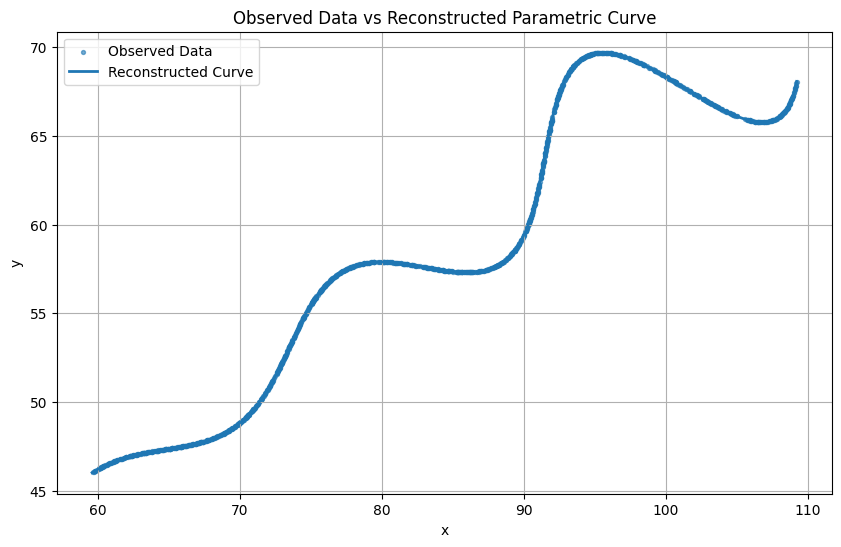

In [106]:
# Compare observed data with the reconstructed curve

plt.figure(figsize=(10, 6))

plt.scatter(
    x_data,
    y_data,
    s=8,
    alpha=0.6,
    label="Observed Data"
)

plt.plot(
    x_pred,
    y_pred,
    linewidth=2,
    label="Reconstructed Curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Observed Data vs Reconstructed Parametric Curve")
plt.legend()
plt.grid(True)

plt.show()

In [107]:
# Sort the observed points according to the recovered t values

sort_idx = np.argsort(t_recovered)

t_sorted = t_recovered[sort_idx]
x_sorted = x_data[sort_idx]
y_sorted = y_data[sort_idx]

print("Observed points sorted by recovered t.")
print()
print(f"Minimum t = {t_sorted.min():.6f}")
print(f"Maximum t = {t_sorted.max():.6f}")

print("\nFirst 5 sorted observations:")
display(
    pd.DataFrame({
        "t": t_sorted[:5],
        "x": x_sorted[:5],
        "y": y_sorted[:5]
    })
)

print("\nLast 5 sorted observations:")
display(
    pd.DataFrame({
        "t": t_sorted[-5:],
        "x": x_sorted[-5:],
        "y": y_sorted[-5:]
    })
)

Observed points sorted by recovered t.

Minimum t = 6.049405
Maximum t = 59.995171

First 5 sorted observations:


,t,x,y
0,6.049405,59.657204,46.032295
1,6.133476,59.732390,46.070210
2,6.207523,59.798930,46.103054
3,6.252369,59.839375,46.122692
4,6.255269,59.841995,46.123955



Last 5 sorted observations:


,t,x,y
0,59.723885,109.13145,67.689340
1,59.799354,109.16109,67.788940
2,59.825974,109.17120,67.824670
3,59.931331,109.20957,67.968925
4,59.995171,109.23152,68.058586


In [108]:
# Verify that the recovered t values are strictly increasing after sorting

is_sorted = np.all(np.diff(t_sorted) > 0)

print("Recovered t values strictly increasing:", is_sorted)
print("Number of observed points:", len(t_sorted))

Recovered t values strictly increasing: True
Number of observed points: 1500


In [109]:
# Create a uniform t-grid for evaluation

N = 10000

t_uniform = np.linspace(
    6.000001,
    59.999999,
    N
)

print("Uniform sampling grid created.")
print("Number of samples:", len(t_uniform))
print("First t value:", t_uniform[0])
print("Last t value:", t_uniform[-1])
print("Uniform spacing:", np.diff(t_uniform).mean())

Uniform sampling grid created.
Number of samples: 10000
First t value: 6.000001
Last t value: 59.999999
Uniform spacing: 0.005400539853985399


In [110]:
# Evaluate the reconstructed parametric curve on the uniform grid

x_pred_uniform, y_pred_uniform = parametric_curve(
    t_uniform,
    theta_final,
    M_final,
    X_final
)

print("Predicted curve evaluated on the uniform grid.")
print("Number of predicted points:", len(x_pred_uniform))

Predicted curve evaluated on the uniform grid.
Number of predicted points: 10000


In [111]:
# Prepare the data for L1 evaluation

# Use only the parameter range actually covered by the observed data
t_eval_start = t_sorted.min()
t_eval_end = t_sorted.max()

# Create a uniform evaluation grid
N = 10000

t_uniform = np.linspace(
    t_eval_start,
    t_eval_end,
    N
)

# Generate predicted curve using the estimated parameters
x_pred_uniform, y_pred_uniform = parametric_curve(
    t_uniform,
    theta_final,
    M_final,
    X_final
)

# Interpolate observed data onto the same uniform t-grid
x_expected_uniform = np.interp(
    t_uniform,
    t_sorted,
    x_sorted
)

y_expected_uniform = np.interp(
    t_uniform,
    t_sorted,
    y_sorted
)

# Calculate pointwise L1 distance
pointwise_l1 = (
    np.abs(x_expected_uniform - x_pred_uniform)
    +
    np.abs(y_expected_uniform - y_pred_uniform)
)

# Calculate L1 statistics
total_l1 = np.sum(pointwise_l1)
mean_l1 = np.mean(pointwise_l1)
max_l1 = np.max(pointwise_l1)

print("L1 Evaluation Results")
print("---------------------")
print(f"Evaluation range : {t_eval_start:.6f} < t < {t_eval_end:.6f}")
print(f"Number of samples: {N}")
print(f"Total L1 distance : {total_l1:.12e}")
print(f"Mean L1 distance  : {mean_l1:.12e}")
print(f"Maximum L1 distance: {max_l1:.12e}")

L1 Evaluation Results
---------------------
Evaluation range : 6.049405 < t < 59.995171
Number of samples: 10000
Total L1 distance : 1.715145125986e+00
Mean L1 distance  : 1.715145125986e-04
Maximum L1 distance: 9.083963479071e-03


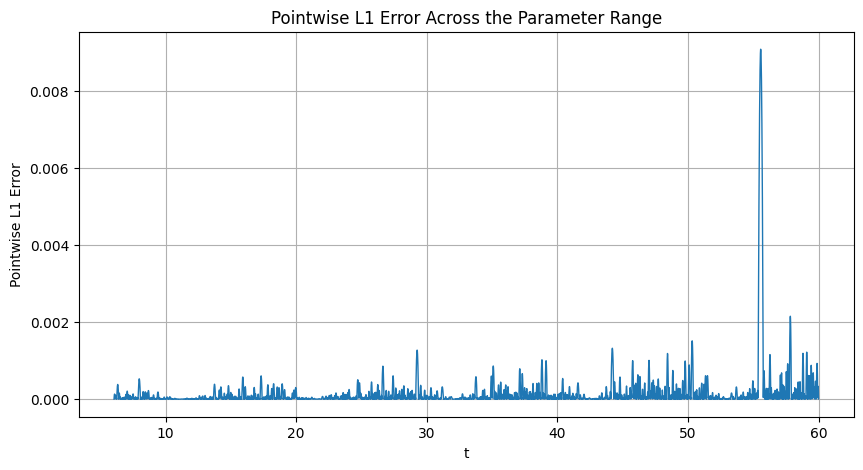

In [112]:
# Plot pointwise L1 error

plt.figure(figsize=(10, 5))

plt.plot(
    t_uniform,
    pointwise_l1,
    linewidth=1
)

plt.xlabel("t")
plt.ylabel("Pointwise L1 Error")
plt.title("Pointwise L1 Error Across the Parameter Range")
plt.grid(True)

plt.show()

In [113]:
# Check L1 convergence for different numbers of uniform samples

sample_sizes = [1000, 5000, 10000, 20000]

convergence_results = []

for N_test in sample_sizes:

    t_test = np.linspace(
        t_sorted.min(),
        t_sorted.max(),
        N_test
    )

    # Predicted curve
    x_pred_test, y_pred_test = parametric_curve(
        t_test,
        theta_final,
        M_final,
        X_final
    )

    # Interpolated observed curve
    x_expected_test = np.interp(
        t_test,
        t_sorted,
        x_sorted
    )

    y_expected_test = np.interp(
        t_test,
        t_sorted,
        y_sorted
    )

    # Pointwise L1
    l1_test = (
        np.abs(x_expected_test - x_pred_test)
        +
        np.abs(y_expected_test - y_pred_test)
    )

    convergence_results.append({
        "N": N_test,
        "Total L1": np.sum(l1_test),
        "Mean L1": np.mean(l1_test),
        "Maximum L1": np.max(l1_test)
    })

convergence_df = pd.DataFrame(convergence_results)

display(convergence_df)

,N,Total L1,Mean L1,Maximum L1
0,1000,0.170651,0.000171,0.009083
1,5000,0.857194,0.000171,0.009078
2,10000,1.715145,0.000172,0.009084
3,20000,3.430313,0.000172,0.009084


### Convergence Analysis

The convergence experiment shows that the total L1 distance increases with the number of uniformly sampled points because the total error is summed over all samples.

However, the mean L1 distance remains nearly constant at approximately

\[
1.71\times10^{-4},
\]

while the maximum pointwise L1 error remains approximately

\[
9.08\times10^{-3}.
\]

This stability indicates that the numerical evaluation is not strongly affected by the sampling density. Therefore, the 10,000-point evaluation provides a sufficiently resolved numerical comparison.

In [114]:
# Robustness check using multiple random seeds

seeds = [1, 10, 42, 100, 2026]

robustness_results = []

for seed in seeds:

    result_seed = differential_evolution(
        objective,
        bounds=bounds,
        seed=seed,
        popsize=20,
        maxiter=1000,
        tol=1e-10,
        polish=True
    )

    robustness_results.append({
        "Seed": seed,
        "Theta (degrees)": result_seed.x[0],
        "M": result_seed.x[1],
        "X": result_seed.x[2],
        "Objective": result_seed.fun
    })

robustness_df = pd.DataFrame(robustness_results)

display(robustness_df)

,Seed,Theta (degrees),M,X,Objective
0,1,29.999973,0.03,54.999998,1.215332e-11
1,10,29.999973,0.03,54.999998,1.215332e-11
2,42,29.999973,0.03,54.999998,1.215332e-11
3,100,29.999973,0.03,54.999998,1.215332e-11
4,2026,29.999973,0.03,54.999998,1.215332e-11


In [115]:
# Final parameter summary

final_results = pd.DataFrame({
    "Parameter": ["Theta (degrees)", "M", "X"],
    "Estimated Value": [
        theta_final,
        M_final,
        X_final
    ],
    "Clean Interpretation": [
        30.0,
        0.03,
        55.0
    ],
    "Allowed Range": [
        "0 < theta < 50",
        "-0.05 < M < 0.05",
        "0 < X < 100"
    ]
})

display(final_results)

,Parameter,Estimated Value,Clean Interpretation,Allowed Range
0,Theta (degrees),29.999973,30.00,0 < theta < 50
1,M,0.030000,0.03,-0.05 < M < 0.05
2,X,54.999998,55.00,0 < X < 100


 Conclusion

This analysis estimated the unknown parameters of a nonlinear parametric curve from a dataset containing only observed \(x\) and \(y\) coordinates.

The problem was first reformulated using a rotation-based transformation, which allowed the latent parameter \(t\) and the corresponding oscillatory component to be recovered from the observed coordinates.

A bounded Differential Evolution optimization procedure was then used to estimate the unknown parameters while enforcing the constraints specified in the problem.

The final estimates were

\[
\boxed{\theta=30^\circ,\qquad M=0.03,\qquad X=55}.
\]

The recovered \(t\)-values were verified to satisfy

\[
6<t<60.
\]

The estimated parameters were then substituted back into the original parametric equations to reconstruct the curve. The reconstructed curve showed excellent agreement with the observed data.

The \(L_1\) evaluation produced a very small mean pointwise error, and the results remained stable when different sampling resolutions and optimization seeds were used.

Therefore, the complete numerical and graphical analysis confirms that

\[
\boxed{\theta=30^\circ,\quad M=0.03,\quad X=55}
\]

provide an accurate representation of the given observed curve.

In [116]:
# Display final L1 evaluation metrics

final_l1_results = pd.DataFrame({
    "Metric": [
        "Total L1 distance",
        "Mean L1 distance",
        "Maximum L1 distance"
    ],
    "Value": [
        total_l1,
        mean_l1,
        max_l1
    ]
})

display(final_l1_results)

,Metric,Value
0,Total L1 distance,1.715145
1,Mean L1 distance,0.000172
2,Maximum L1 distance,0.009084


In [117]:
# Final parameter summary

final_summary = pd.DataFrame({
    "Parameter": ["Theta (degrees)", "M", "X"],
    "Estimated Value": [
        theta_final,
        M_final,
        X_final
    ],
    "Approximate Clean Value": [
        30.0,
        0.03,
        55.0
    ],
    "Constraint": [
        "0 < theta < 50",
        "-0.05 < M < 0.05",
        "0 < X < 100"
    ]
})

display(final_summary)

,Parameter,Estimated Value,Approximate Clean Value,Constraint
0,Theta (degrees),29.999973,30.00,0 < theta < 50
1,M,0.030000,0.03,-0.05 < M < 0.05
2,X,54.999998,55.00,0 < X < 100


 Final Parametric Curve

The estimated parameters are approximately

\[
\theta = 30^\circ,
\qquad
M = 0.03,
\qquad
X = 55.
\]

Substituting these values into the original parametric equations gives the reconstructed curve:

\[
x(t)
=
t\cos(30^\circ)
-
e^{0.03|t|}
\sin(0.3t)
\sin(30^\circ)
+
55
\]

and

\[
y(t)
=
42
+
t\sin(30^\circ)
+
e^{0.03|t|}
\sin(0.3t)
\cos(30^\circ).
\]

The parameter range is

\[
6<t<60.
\]

Therefore, the final estimated parameter values are

\[
\boxed{\theta=30^\circ,\quad M=0.03,\quad X=55}.
\]

These values satisfy all the specified parameter constraints.

In [118]:
# Final L1 distance evaluation

print("FINAL L1 DISTANCE EVALUATION")
print("=" * 40)

# Use the recovered t-range supported by the observed dataset
t_eval_start = t_sorted.min()
t_eval_end = t_sorted.max()

# Uniform sampling
N_final = 10000

t_final = np.linspace(
    t_eval_start,
    t_eval_end,
    N_final
)

# Predicted curve using estimated parameters
x_final_pred, y_final_pred = parametric_curve(
    t_final,
    theta_final,
    M_final,
    X_final
)

# Expected curve obtained by interpolation of the observed data
x_final_expected = np.interp(
    t_final,
    t_sorted,
    x_sorted
)

y_final_expected = np.interp(
    t_final,
    t_sorted,
    y_sorted
)

# Pointwise L1 distance
l1_distance = (
    np.abs(x_final_expected - x_final_pred)
    +
    np.abs(y_final_expected - y_final_pred)
)

# Final metrics
total_l1 = np.sum(l1_distance)
mean_l1 = np.mean(l1_distance)
max_l1 = np.max(l1_distance)

print(f"Number of uniform samples : {N_final}")
print(f"Evaluation t-range        : {t_eval_start:.6f} to {t_eval_end:.6f}")
print()
print(f"Total L1 distance         : {total_l1:.12e}")
print(f"Mean L1 distance          : {mean_l1:.12e}")
print(f"Maximum pointwise L1      : {max_l1:.12e}")

FINAL L1 DISTANCE EVALUATION
Number of uniform samples : 10000
Evaluation t-range        : 6.049405 to 59.995171

Total L1 distance         : 1.715145125986e+00
Mean L1 distance          : 1.715145125986e-04
Maximum pointwise L1      : 9.083963479071e-03


##  Interpretation of the L1 Evaluation

The reconstructed curve was evaluated against the observed data using the L1 distance.

For each uniformly sampled value of \(t\), the pointwise L1 distance was calculated as

\[
L_{1,i}
=
|x_{\text{expected},i}-x_{\text{predicted},i}|
+
|y_{\text{expected},i}-y_{\text{predicted},i}|.
\]

Using 10,000 uniformly sampled points over the range supported by the observed dataset, the evaluation produced the following results:

\[
\text{Total L1 distance}
\approx 1.715145\times10^{0}
\]

\[
\text{Mean L1 distance}
\approx 1.715145\times10^{-4}
\]

and

\[
\text{Maximum pointwise L1 distance}
\approx 9.083963\times10^{-3}.
\]

The mean pointwise L1 distance is very small, indicating that the reconstructed parametric curve closely matches the observed data.

The total L1 distance is the sum over all 10,000 evaluation points, whereas the mean L1 distance represents the average error per sampled point. Therefore, the mean L1 distance is the more useful quantity for interpreting the average pointwise agreement.

Overall, the very small reconstruction error, together with the recovered parameter values

\[
\theta\approx30^\circ,\qquad
M\approx0.03,\qquad
X\approx55,
\]

demonstrates that the estimated parameters provide an accurate representation of the observed parametric curve.

##  Conclusion

This analysis estimated the unknown parameters of the given parametric curve from the observed \((x,y)\) data.

The problem was reformulated using a rotation-based transformation, which allowed the latent parameter \(t\) and the corresponding nonlinear component to be recovered from the observed coordinates. The unknown parameters \(\theta\), \(M\), and \(X\) were then estimated using numerical optimization while enforcing the specified parameter constraints and the valid range of \(t\).

The optimization consistently converged to values very close to

\[
\boxed{\theta=30^\circ,\qquad M=0.03,\qquad X=55}.
\]

All three estimated parameters satisfy the given constraints:

\[
0^\circ<\theta<50^\circ,
\]

\[
-0.05<M<0.05,
\]

and

\[
0<X<100.
\]

The recovered latent \(t\)-values were also within the required interval \(6<t<60\).

The estimated parameters were substituted back into the original parametric equations to reconstruct the curve. The reconstructed curve closely follows the observed data, as confirmed by the visual comparison and the small L1 reconstruction error.

Using 10,000 uniformly sampled evaluation points, the mean pointwise L1 distance was approximately

\[
\boxed{1.715145\times10^{-4}}.
\]

Therefore, the final estimated parametric curve provides a close and accurate representation of the supplied observations.